In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/team_stats_2003_2023.csv')
df.head()

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


In [4]:
target = 'win_loss_perc'

exclude_cols = ['year', 'team', 'wins', 'losses', target, 'ties', 'points_diff', 'mov']

df_clean = df.drop(columns=[col for col in exclude_cols if col in df.columns])

df_clean = df_clean.dropna()
df_clean.head()

,points,points_opp,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,...,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot
0,348,238,16,5039,1042,4.8,24,11,294,320,...,1607,9,3.4,91,111,998,26,27.9,11.3,-136.51
1,311,261,16,4609,968,4.8,34,15,266,257,...,1817,14,3.7,99,103,913,22,28.1,17.2,-177.92
2,243,279,16,4348,980,4.4,34,17,268,293,...,1664,13,3.9,96,106,891,22,21.9,17.6,-230.07
3,283,299,16,4951,936,5.3,20,6,274,312,...,1635,8,4.0,78,69,550,15,32.4,11.8,-107.89
4,391,281,16,4929,1009,4.9,38,19,259,217,...,2674,18,4.8,115,126,970,23,31.8,16.6,-220.50


In [5]:
X = df_clean
y = df[target][df_clean.index]

In [6]:
offensive_features = ['points', 'total_yards', 'plays_offense', 'yds_per_play_offense', 
                      'first_down', 'pass_cmp', 'pass_att', 'pass_yds', 'pass_td', 
                      'pass_int', 'pass_net_yds_per_att', 'pass_fd', 'rush_att', 
                      'rush_yds', 'rush_td', 'rush_yds_per_att', 'rush_fd']

defensive_features = ['points_opp', 'turnovers', 'fumbles_lost']

efficiency_features = ['score_pct', 'turnover_pct', 'exp_pts_tot', 'penalties', 
                       'penalties_yds', 'pen_fd']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
## MODELS WE CAN USE

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),

    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),

    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    min_split_gain=0.0,
    random_state=42,
    verbose=-1
),

    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

In [10]:
def evaluate_model(name, model, X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test):
    scaled_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']

    if name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Predictions': y_pred
    }

In [11]:
results = []

for name, model in models.items():
    result = evaluate_model(
        name, model,
        X_train, X_test,
        X_train_scaled, X_test_scaled,
        y_train, y_test
    )
    results.append(result)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'Predictions'}
    for r in results
]).sort_values(by='R2', ascending=False)

results_df

,Model,MSE,RMSE,MAE,R2
2,Lasso Regression,0.005642,0.075114,0.061829,0.855393
1,Ridge Regression,0.005843,0.076442,0.062738,0.850233
0,Linear Regression,0.005944,0.077095,0.063231,0.847663
4,Gradient Boosting,0.006817,0.082563,0.064848,0.825288
3,Random Forest,0.006845,0.082732,0.065439,0.824574
6,LightGBM,0.006895,0.083035,0.066617,0.823287
5,XGBoost,0.007425,0.086170,0.066524,0.809689
7,SVR,0.007524,0.086743,0.069271,0.807152


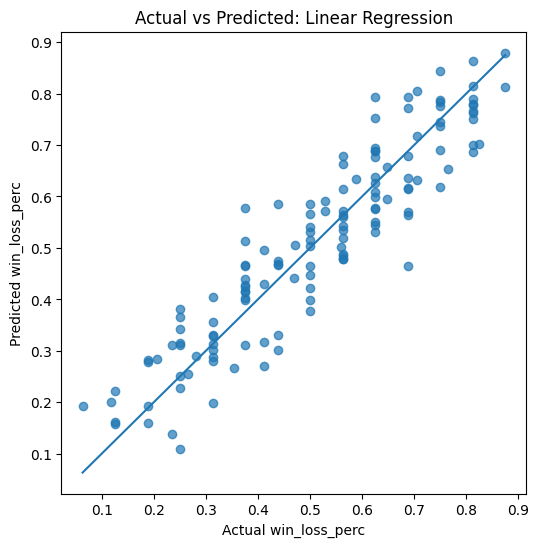

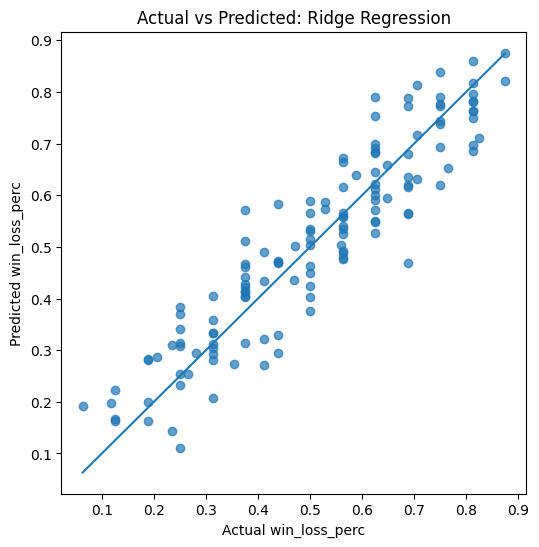

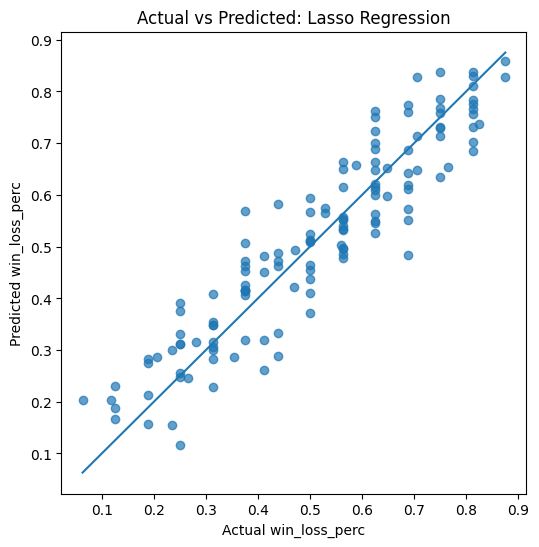

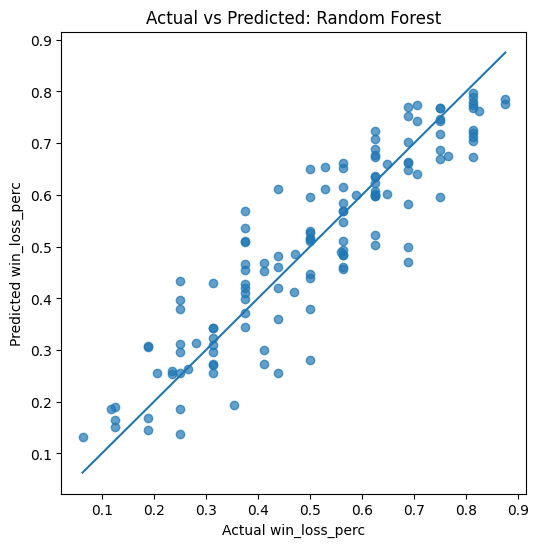

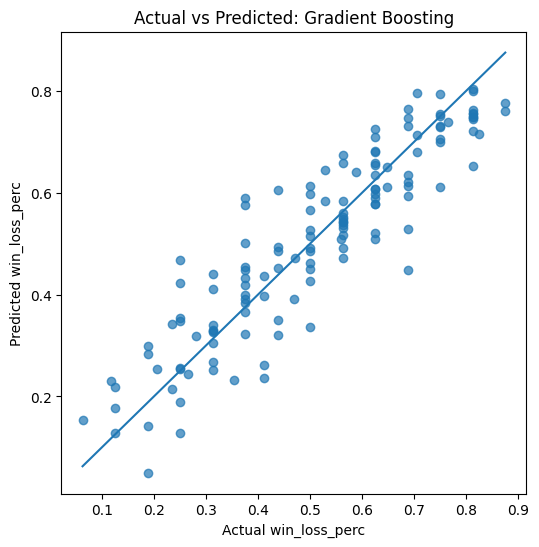

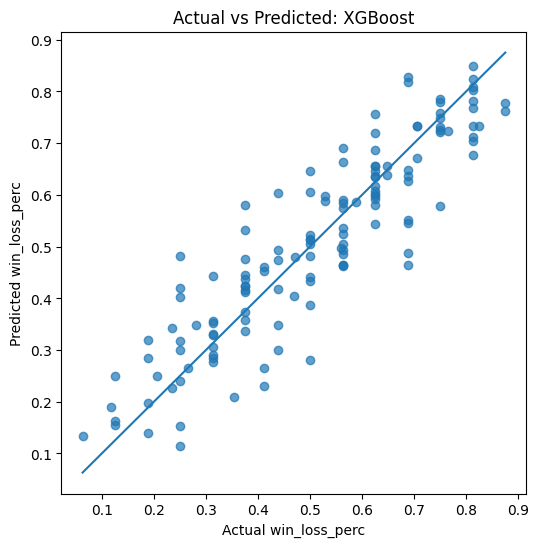

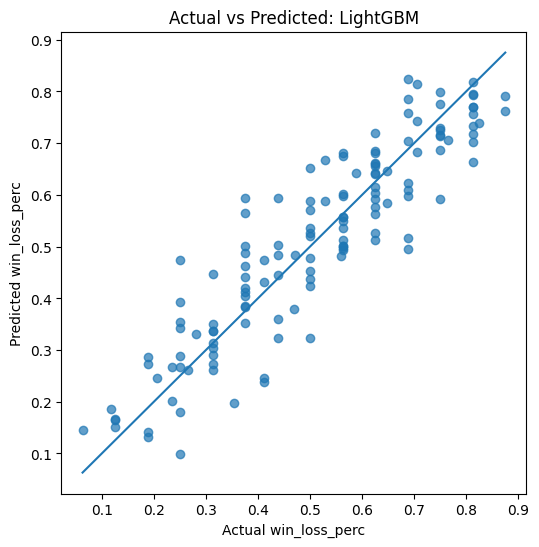

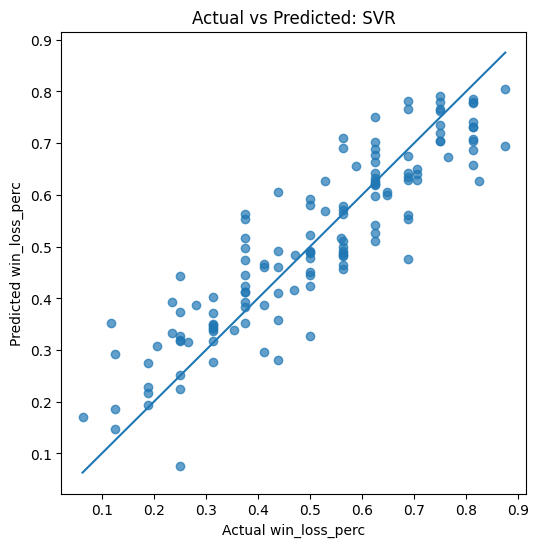

In [12]:
for result in results:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, result['Predictions'], alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel("Actual win_loss_perc")
    plt.ylabel("Predicted win_loss_perc")
    plt.title(f"Actual vs Predicted: {result['Model']}")
    plt.show()

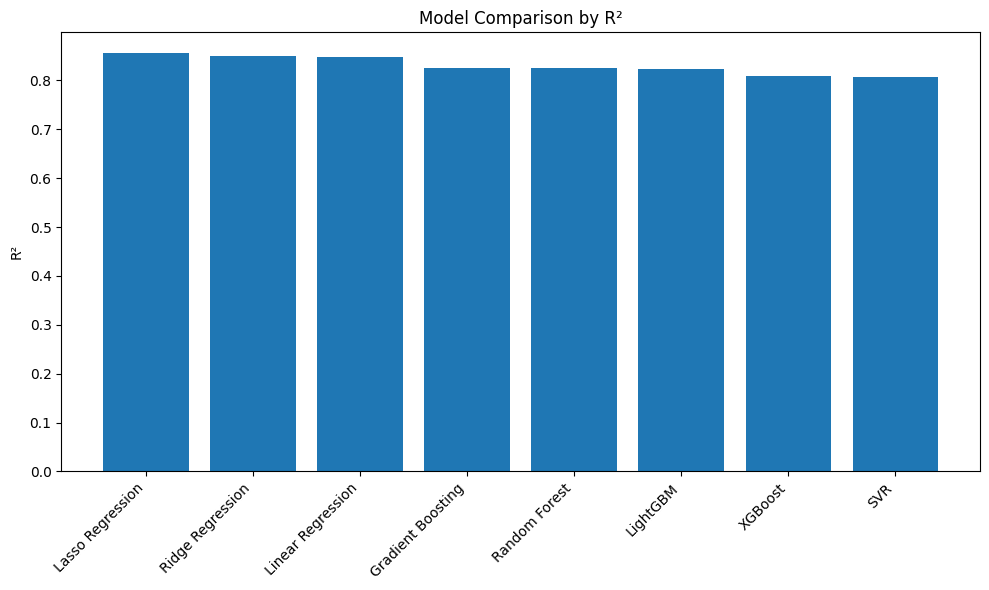

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['R2'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('R²')
plt.title('Model Comparison by R²')
plt.tight_layout()
plt.show()

In [14]:
# Step 1 — Rebuild the test set with team/year info
import pandas as pd
test_info = df.loc[X_test.index, ['year', 'team', 'win_loss_perc']].copy()

# Step 2 — Add each model's predictions as a new column
for result in results:
    col_name = result['Model'].replace(' ', '_')
    test_info[f'pred_{col_name}'] = result['Predictions']

# Step 3 — Export to your folder
test_info.to_csv(r'C:\Users\user\Desktop\AiMsu\CSE482\predictions_for_powerbi.csv', index=False)
print("Saved successfully!")
print(test_info.head())

Saved successfully!
     year                 team  win_loss_perc  pred_Linear_Regression  \
361  2014       Houston Texans          0.563                0.679120   
158  2007  San Francisco 49ers          0.313                0.198216   
481  2018       Miami Dolphins          0.438                0.301063   
639  2022    Arizona Cardinals          0.235                0.312041   
275  2011  Washington Redskins          0.313                0.328341   

     pred_Ridge_Regression  pred_Lasso_Regression  pred_Random_Forest  \
361               0.672961               0.649095             0.66056   
158               0.206952               0.227664             0.25631   
481               0.295033               0.288791             0.25592   
639               0.310285               0.299582             0.25269   
275               0.333922               0.347651             0.34225   

     pred_Gradient_Boosting  pred_XGBoost  pred_LightGBM  pred_SVR  
361                0.658732      

In [15]:
# Export FULL dataset for Power BI
df.to_csv(r'C:\Users\user\Desktop\AiMsu\CSE482\full_stats_powerbi.csv', index=False)
print("Full stats saved!")

Full stats saved!


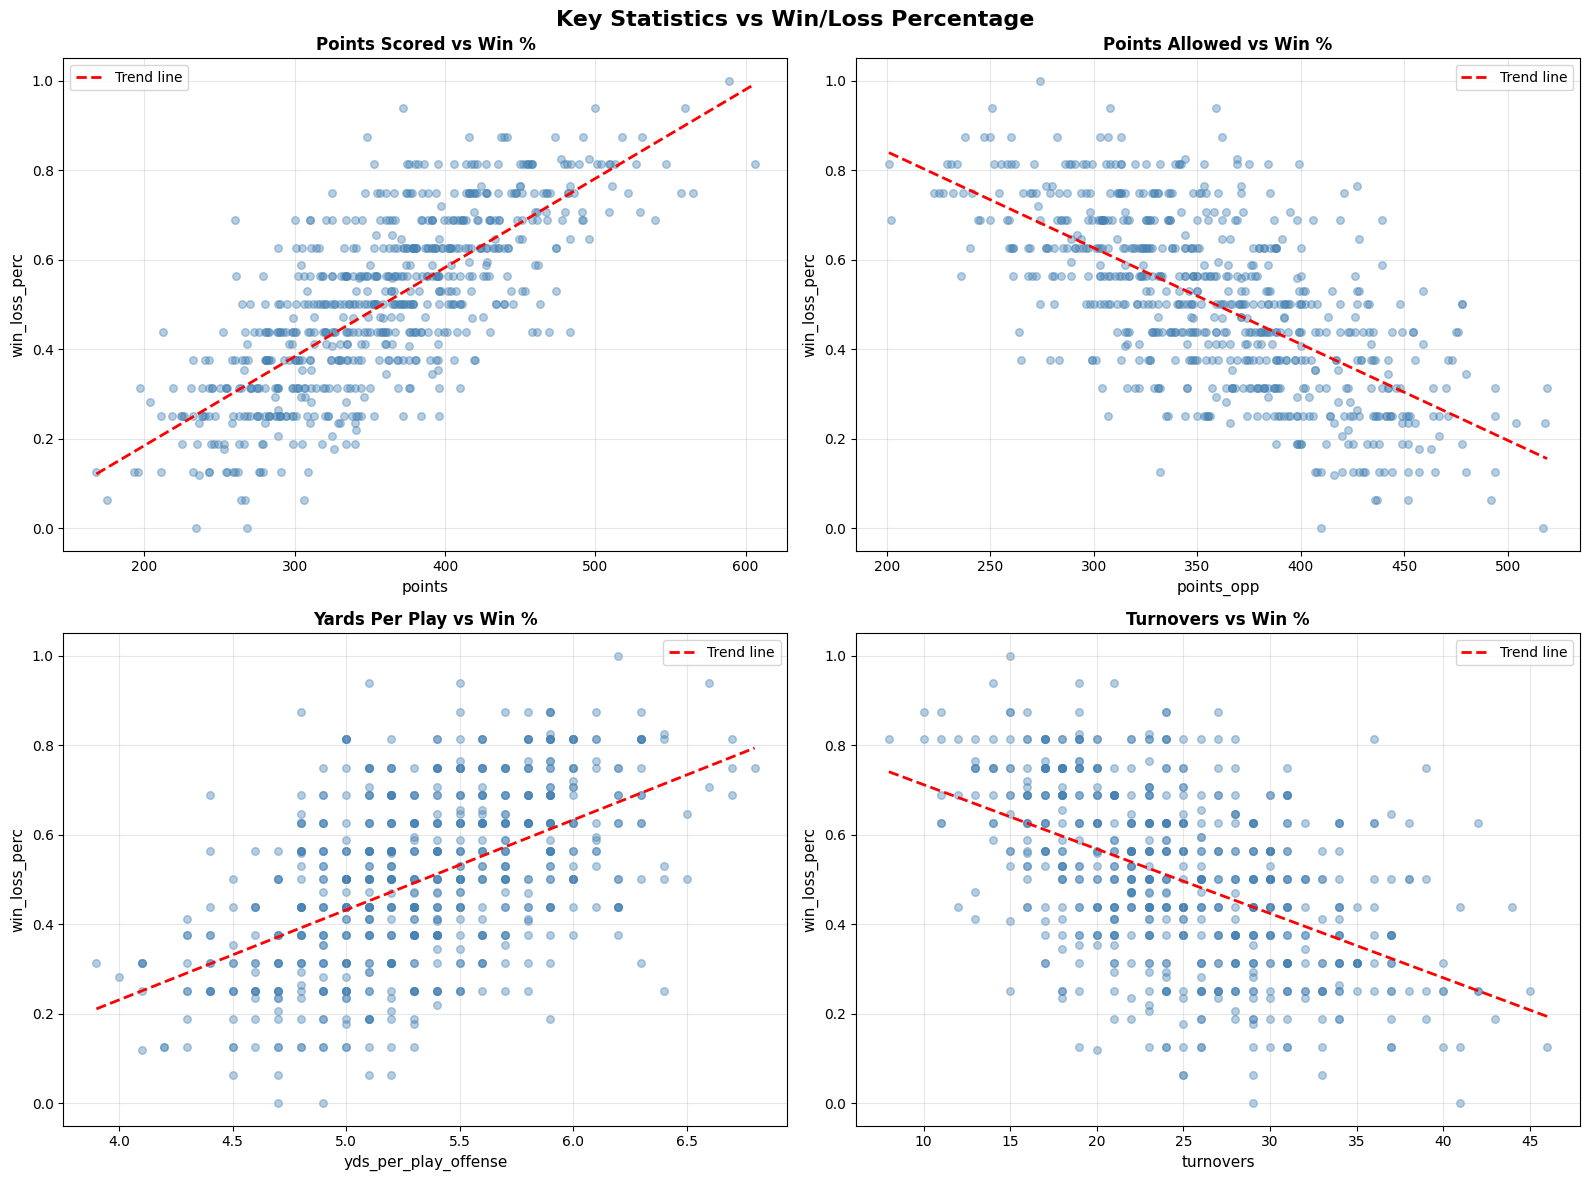

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Statistics vs Win/Loss Percentage', fontsize=16, fontweight='bold')

scatter_configs = [
    ('points', 'Points Scored vs Win %'),
    ('points_opp', 'Points Allowed vs Win %'),
    ('yds_per_play_offense', 'Yards Per Play vs Win %'),
    ('turnovers', 'Turnovers vs Win %'),
]

for ax, (col, title) in zip(axes.flatten(), scatter_configs):
    ax.scatter(df[col], df['win_loss_perc'], alpha=0.4, s=30, color='steelblue')
    m, b = np.polyfit(df[col].dropna(), df['win_loss_perc'][df[col].dropna().index], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=2, label='Trend line')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('win_loss_perc', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

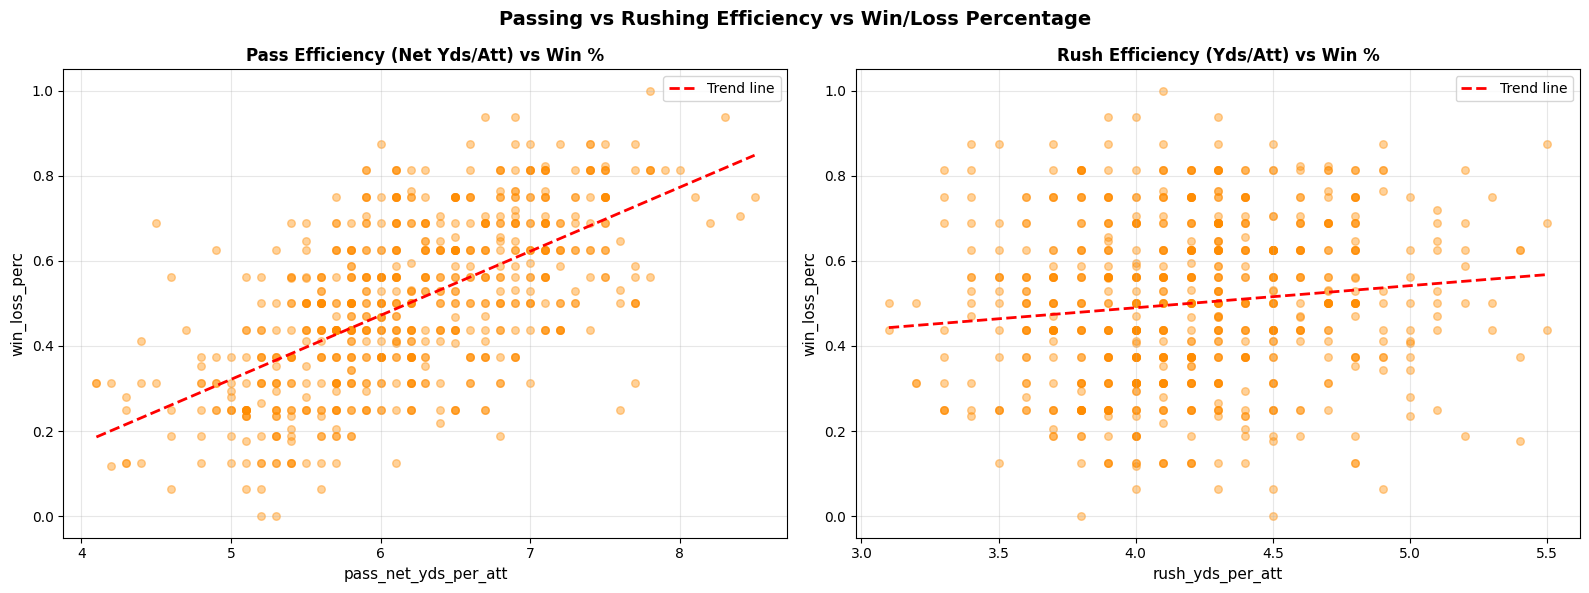

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Passing vs Rushing Efficiency vs Win/Loss Percentage', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes, [
    ('pass_net_yds_per_att', 'Pass Efficiency (Net Yds/Att) vs Win %'),
    ('rush_yds_per_att', 'Rush Efficiency (Yds/Att) vs Win %')
]):
    ax.scatter(df[col], df['win_loss_perc'], alpha=0.4, s=30, color='darkorange')
    m, b = np.polyfit(df[col].dropna(), df['win_loss_perc'][df[col].dropna().index], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=2, label='Trend line')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('win_loss_perc', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

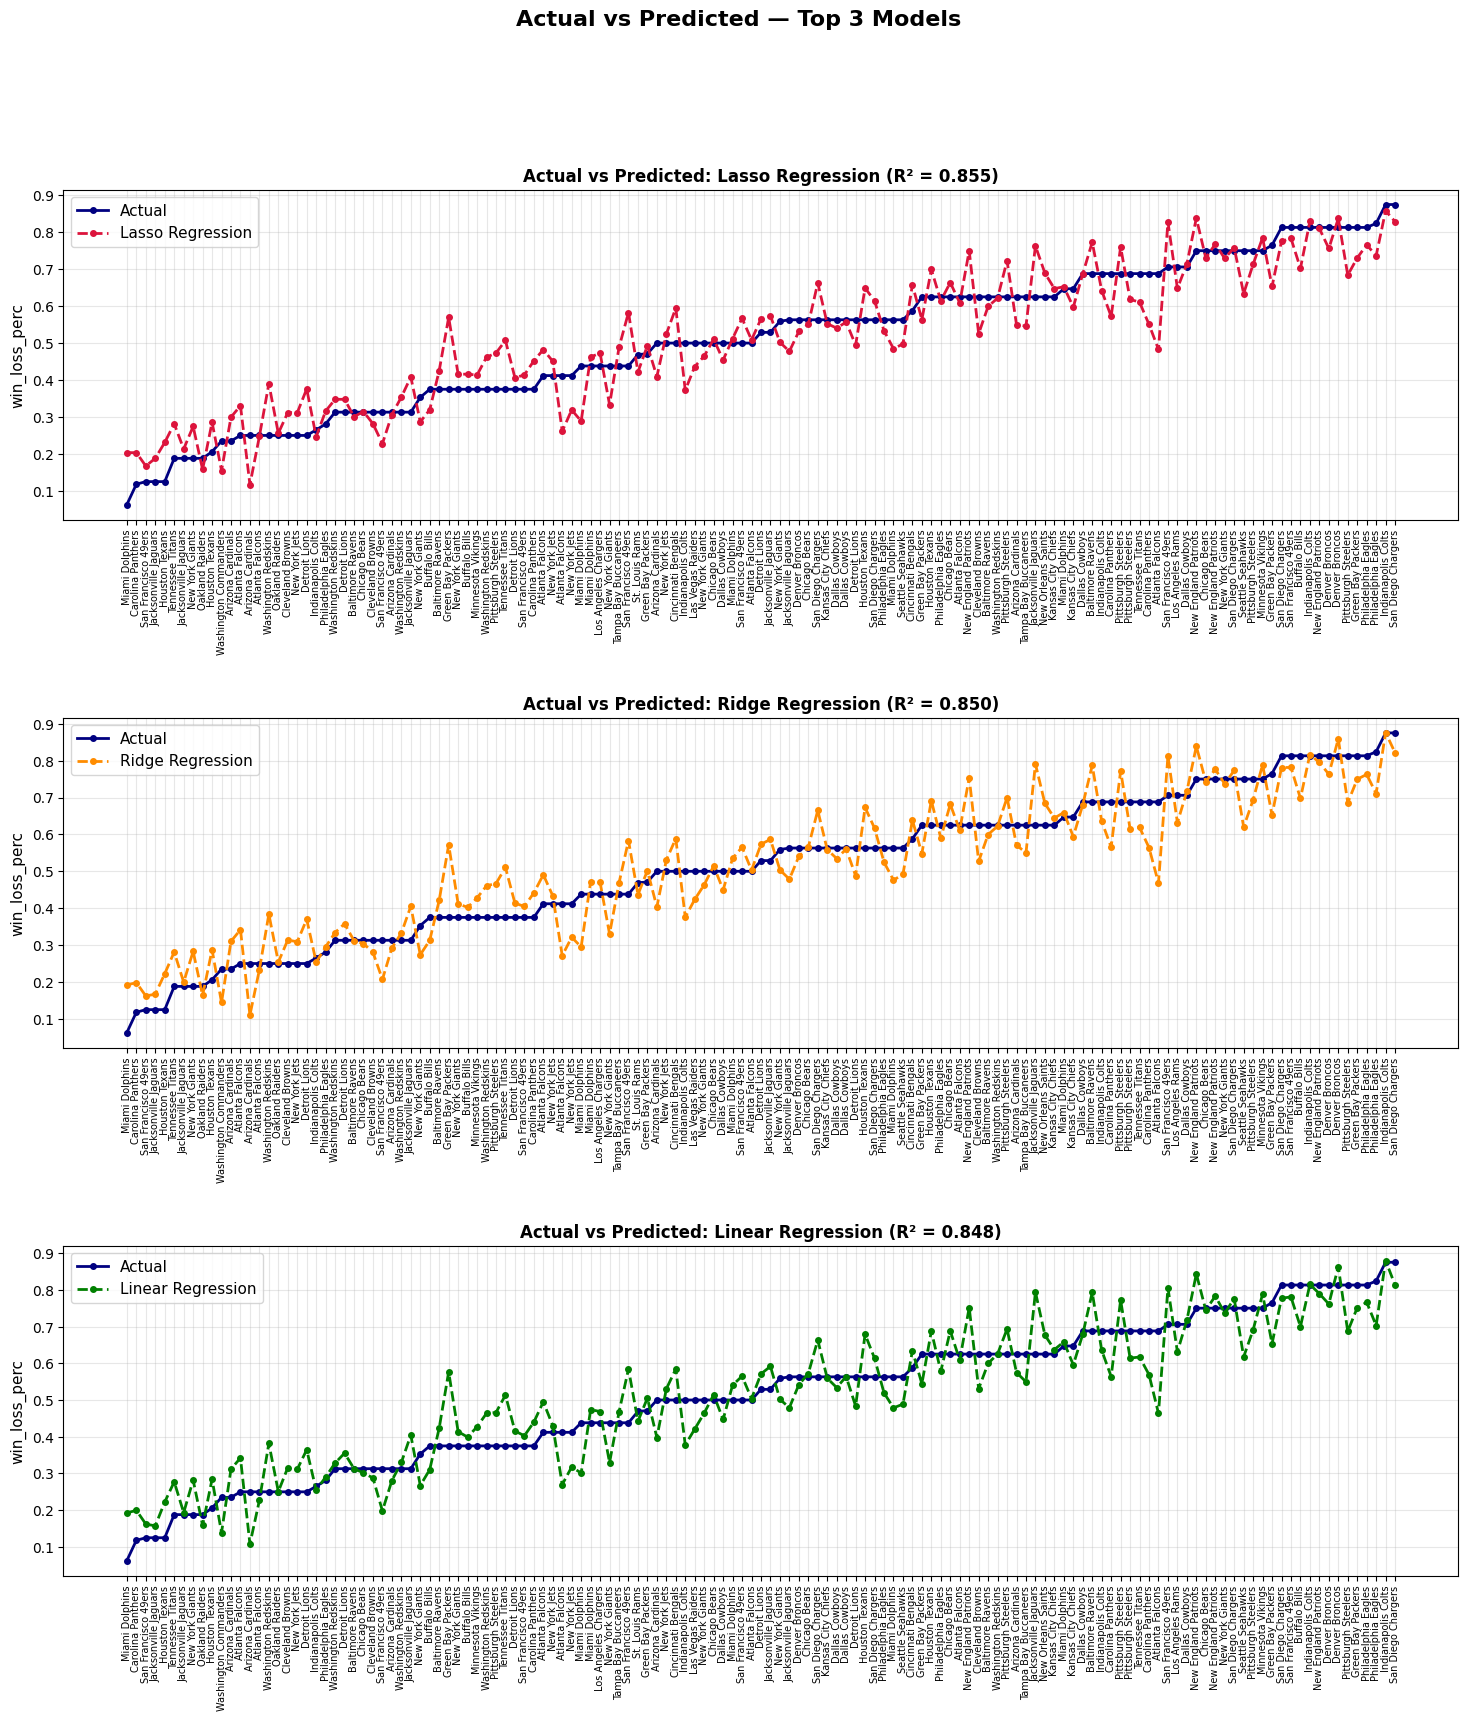

In [26]:
top_3_models = ['Lasso Regression', 'Ridge Regression', 'Linear Regression']

teams = df.loc[X_test.index, 'team'].values
actual = y_test.values
sort_idx = np.argsort(actual)
teams_sorted = teams[sort_idx]
actual_sorted = actual[sort_idx]

colors = ['crimson', 'darkorange', 'green']

fig, axes = plt.subplots(3, 1, figsize=(18, 18))
fig.suptitle('Actual vs Predicted — Top 3 Models', fontsize=16, fontweight='bold')

for ax, model_name, color in zip(axes, top_3_models, colors):
    preds = None
    for result in results:
        if result['Model'] == model_name:
            preds = result['Predictions'][sort_idx]
    
    x = np.arange(len(teams_sorted))
    ax.plot(x, actual_sorted, marker='o', color='navy', linewidth=2, markersize=4, label='Actual')
    ax.plot(x, preds, marker='o', color=color, linewidth=2, markersize=4, linestyle='--', label=model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(teams_sorted, rotation=90, fontsize=7)
    ax.set_ylabel('win_loss_perc', fontsize=11)
    ax.set_title(f'Actual vs Predicted: {model_name} (R² = {results_df[results_df["Model"]==model_name]["R2"].values[0]:.3f})', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.subplots_adjust(hspace=0.6)
plt.show()

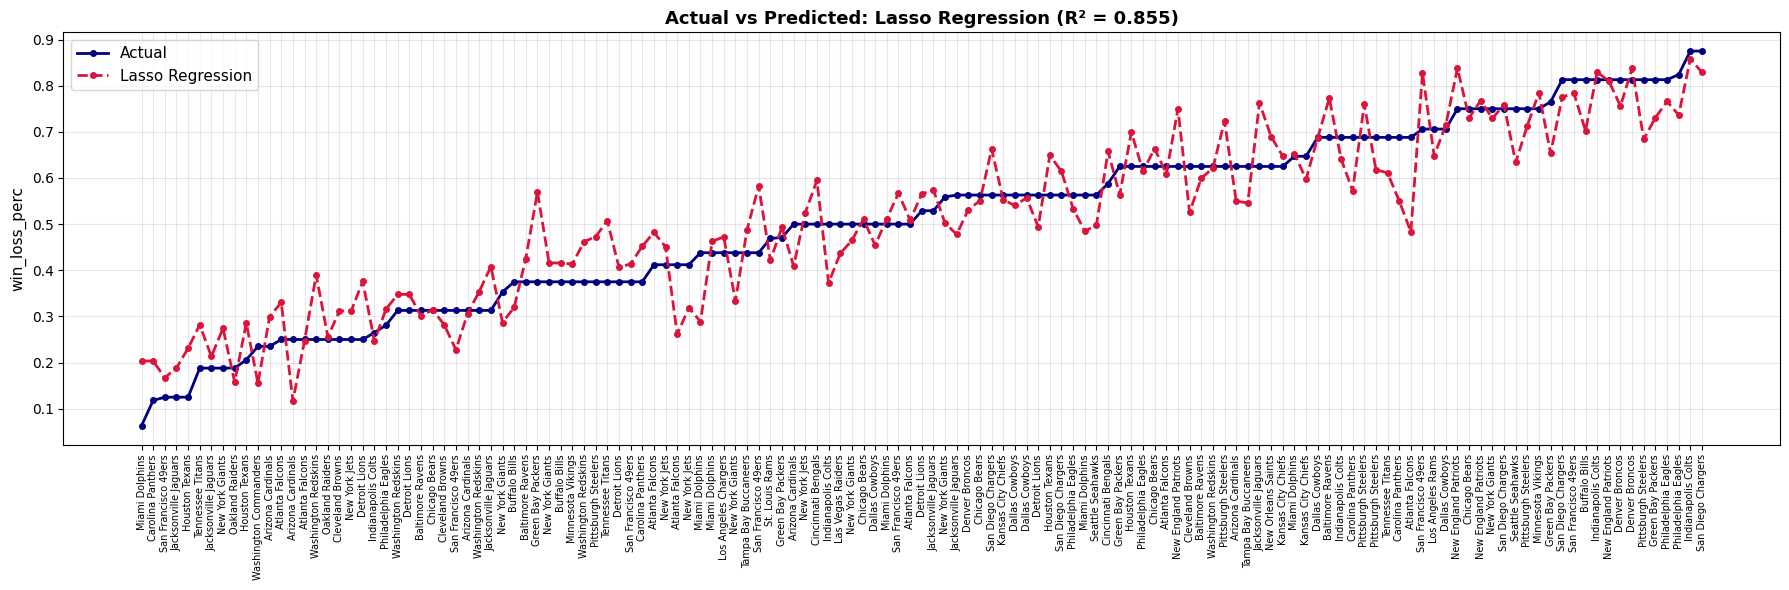

In [27]:
teams = df.loc[X_test.index, 'team'].values
actual = y_test.values
sort_idx = np.argsort(actual)
teams_sorted = teams[sort_idx]
actual_sorted = actual[sort_idx]

for result in results:
    if result['Model'] == 'Lasso Regression':
        preds = result['Predictions'][sort_idx]

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(teams_sorted))
ax.plot(x, actual_sorted, marker='o', color='navy', linewidth=2, markersize=4, label='Actual')
ax.plot(x, preds, marker='o', color='crimson', linewidth=2, markersize=4, linestyle='--', label='Lasso Regression')
ax.set_xticks(x)
ax.set_xticklabels(teams_sorted, rotation=90, fontsize=7)
ax.set_ylabel('win_loss_perc', fontsize=11)
ax.set_title('Actual vs Predicted: Lasso Regression (R² = 0.855)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

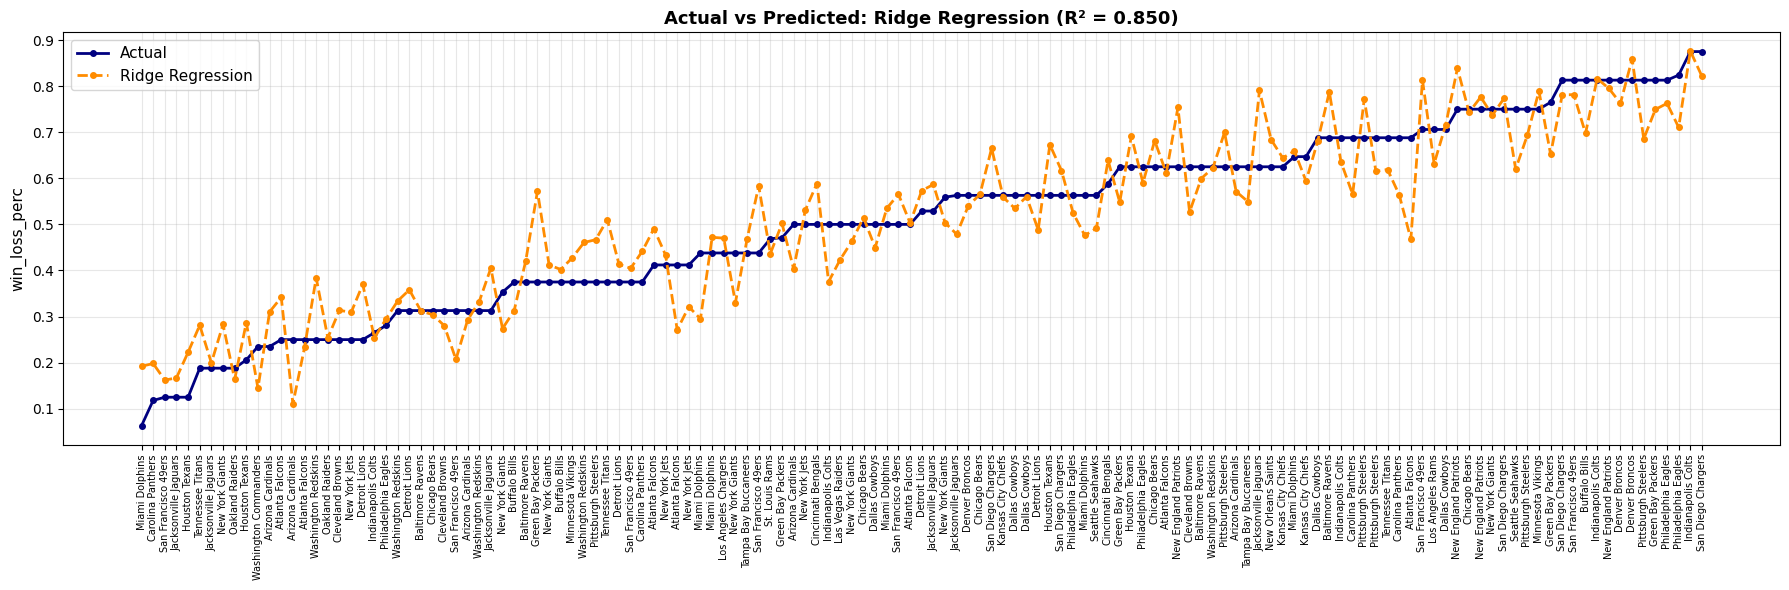

In [28]:
for result in results:
    if result['Model'] == 'Ridge Regression':
        preds = result['Predictions'][sort_idx]

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(teams_sorted))
ax.plot(x, actual_sorted, marker='o', color='navy', linewidth=2, markersize=4, label='Actual')
ax.plot(x, preds, marker='o', color='darkorange', linewidth=2, markersize=4, linestyle='--', label='Ridge Regression')
ax.set_xticks(x)
ax.set_xticklabels(teams_sorted, rotation=90, fontsize=7)
ax.set_ylabel('win_loss_perc', fontsize=11)
ax.set_title('Actual vs Predicted: Ridge Regression (R² = 0.850)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

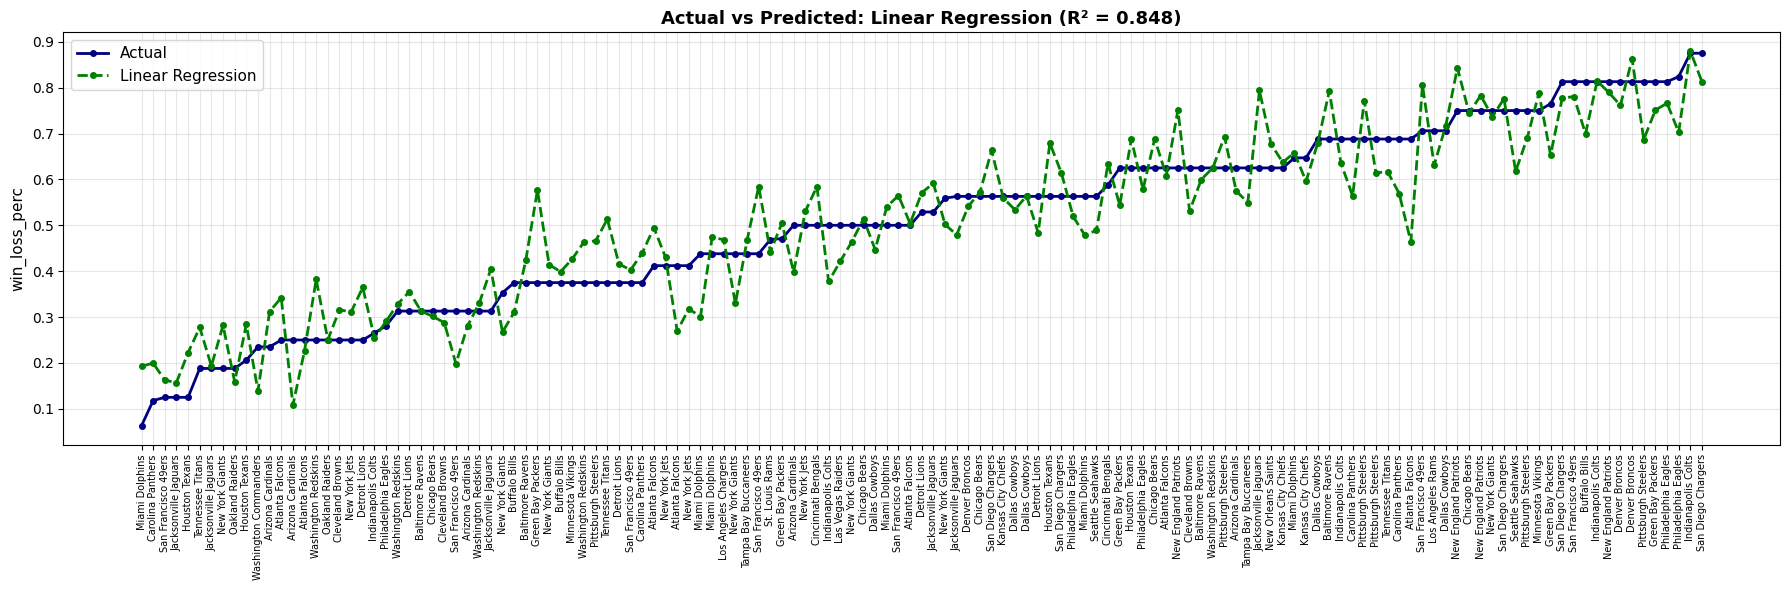

In [29]:
for result in results:
    if result['Model'] == 'Linear Regression':
        preds = result['Predictions'][sort_idx]

fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(teams_sorted))
ax.plot(x, actual_sorted, marker='o', color='navy', linewidth=2, markersize=4, label='Actual')
ax.plot(x, preds, marker='o', color='green', linewidth=2, markersize=4, linestyle='--', label='Linear Regression')
ax.set_xticks(x)
ax.set_xticklabels(teams_sorted, rotation=90, fontsize=7)
ax.set_ylabel('win_loss_perc', fontsize=11)
ax.set_title('Actual vs Predicted: Linear Regression (R² = 0.848)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()